In [1]:
!pip install Biopython

In [2]:
import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dropout, Activation, Flatten
from keras.layers import Conv1D, MaxPooling1D, Embedding, LSTM, Dense, Bidirectional, TimeDistributed

from matplotlib import pyplot as plt

from Bio.Seq import Seq

### Read data

In [3]:
filename = "training_data.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [4]:
b = open('ghl_gold.fa','r')
bind = b.readlines()
b.close()

u = open('ghl_gold_random.fa','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [5]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [6]:
print(len(bind), len(unbind))

1400090 1400090


##### Reverse complement

In [7]:
bind_rev = list(range(len(bind)))

for i in range(len(bind)):
  seq = Seq(bind[i])
  rev = seq.reverse_complement()
  bind_rev[i] = str(rev)

unbind_rev = list(range(len(unbind)))

for i in range(len(unbind)):
  seq = Seq(unbind[i])
  rev = seq.reverse_complement()
  unbind_rev[i] = str(rev)

In [8]:
bind_fb = bind + bind_rev
unbind_fb = unbind + unbind_rev

In [9]:
bind_label = [1 for i in range(len(bind_fb))]
unbind_label = [0 for i in range(len(unbind_fb))]

In [10]:
bind_dict = {"seq":bind_fb, "label":bind_label}
unbind_dict = {"seq":unbind_fb, "label":unbind_label}

In [11]:
bind_df = pd.DataFrame(bind_dict)
unbind_df = pd.DataFrame(unbind_dict)

In [12]:
df = pd.concat([bind_df, unbind_df])

##### split the dataset

In [13]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [14]:
x = new_df.seq
y = new_df.label

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

##### One-hot Encoding

In [16]:
LE = LabelEncoder()
LE.fit(['A', 'C', 'G', 'T', 'N'])

LabelEncoder()

In [17]:
start = datetime.now()

for index, row in x_train.items():
  x_train[index] = LE.transform(list(row))

for index, row in x_test.items():
  x_test[index] = LE.transform(list(row))

x_train = to_categorical(x_train.values.tolist())
x_t = to_categorical(x_test.values.tolist())

y_train = to_categorical(y_train.values.tolist())
y_t = to_categorical(y_test.values.tolist())

end = datetime.now()
print("encoding running time : "+str(end-start))

encoding running time : 0:05:45.867830


### CNN + RNN model

In [21]:
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=7, strides=1, padding='valid', activation='relu', input_shape=(20, 5)))
model.add(MaxPooling1D(pool_size=3, strides=1, padding='valid'))

model.add(Bidirectional(LSTM(32, return_sequences=True)))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [22]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_1 (Conv1D)            (None, 14, 64)            2304      
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 12, 64)            0         
_________________________________________________________________
bidirectional_1 (Bidirection (None, 12, 64)            24832     
_________________________________________________________________
bidirectional_2 (Bidirection (None, 64)                24832     
_________________________________________________________________
dense_2 (Dense)              (None, 32)                2080      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 2)                

In [23]:
history = model.fit(x_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
112008/112008 [==============================] - 1105s 10ms/step - loss: 0.3530 - accuracy: 0.8457 - val_loss: 0.3200 - val_accuracy: 0.8607
Epoch 2/10
112008/112008 [==============================] - 1103s 10ms/step - loss: 0.3194 - accuracy: 0.8623 - val_loss: 0.3165 - val_accuracy: 0.8630
Epoch 3/10
112008/112008 [==============================] - 1117s 10ms/step - loss: 0.3150 - accuracy: 0.8640 - val_loss: 0.3139 - val_accuracy: 0.8640
Epoch 4/10
112008/112008 [==============================] - 1104s 10ms/step - loss: 0.3139 - accuracy: 0.8646 - val_loss: 0.3140 - val_accuracy: 0.8639
Epoch 5/10
112008/112008 [==============================] - 1084s 10ms/step - loss: 0.3119 - accuracy: 0.8656 - val_loss: 0.3130 - val_accuracy: 0.8645
Epoch 6/10
112008/112008 [==============================] - 1079s 10ms/step - loss: 0.3113 - accuracy: 0.8659 - val_loss: 0.3152 - val_accuracy: 0.8635
Epoch 7/10
112008/112008 [==============================] - 1071s 10ms/step - loss: 0.31

##### Evaluation

Accuracy

In [24]:
score = model.evaluate(x_t, y_t)
print("score = " + str(round(score[1],2)))

35003/35003 [==============================] - 148s 4ms/step - loss: 0.3145 - accuracy: 0.8643
score = 0.86


loss-epoch curve

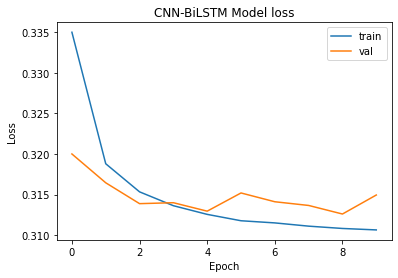

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN-BiLSTM Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [26]:
probs = model.predict(x_t)[:,1]

In [27]:
precision, recall, thresholds = precision_recall_curve(y_test.values, probs)

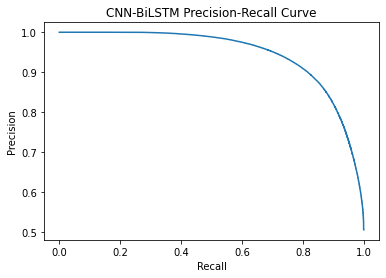

In [28]:
plt.plot(recall, precision)

plt.title('CNN-BiLSTM Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

ROC Curve, AUC

In [29]:
auc = roc_auc_score(y_test.values, probs)
fpr, tpr, _ = roc_curve(y_test.values, probs)

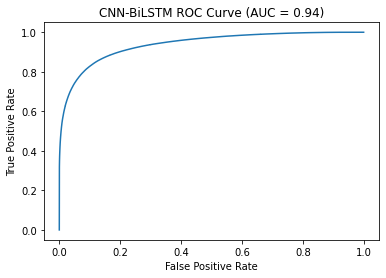

In [30]:
plt.plot(fpr, tpr)
plt.title('CNN-BiLSTM ROC Curve (AUC = ' + str(round(auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()